# Hyperparameter Heston
## Learning rate


In [1]:
# Standard library imports
import os
import time
from pathlib import Path

# Data manipulation and mathematics
import numpy as np
import pandas as pd
from scipy.stats import norm
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
from matplotlib import cm

# Deep learning framework (PyTorch)
import torch
import torch.nn as nn
import torch.optim as optim

# Sweep
import itertools


In [2]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_url = "https://github.com/egil10/fys5429.git"
    repo_dir = "/content/fys5429"

    if not os.path.exists(repo_dir):
        !git clone {repo_url} {repo_dir}
    else:
        !git -C {repo_dir} pull

    os.chdir(os.path.join(repo_dir, "code", "notebooks"))

print(f"Working directory: {os.getcwd()}")


Cloning into '/content/fys5429'...
remote: Enumerating objects: 775, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 775 (delta 68), reused 88 (delta 37), pack-reused 654 (from 1)
Receiving objects: 100% (775/775), 63.95 MiB | 55.02 MiB/s, done.
Resolving deltas: 100% (370/370), done.
Working directory: /content/fys5429/code/notebooks


### Colab setup


In [3]:
# Pathways
data_path = Path("..") / "data" / "generated" / "hs_collocation.parquet"

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    out_dir = Path("/content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda")
else:
    out_dir = Path("..") / "plots" / "eda"

out_dir.mkdir(parents=True, exist_ok=True)
print(f"Plots will be saved to: {out_dir}")


Mounted at /content/drive
Plots will be saved to: /content/drive/MyDrive/GITHUB-COLAB/fys5429/code/plots/eda


In [4]:
# Importing HSPINN() Class
import sys
sys.path.insert(0, "../scripts")
from hspinn import HSPINN
from train_hs import train_pinn


### Global parameters


In [5]:
# Answer to the universe and everything
torch.manual_seed(42)

# Use GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Adding torch backends
torch.backends.cudnn.benchmark = True

# Option Physics for Heston 
S_max = 300.0
T_max = 1.0
K = 100.0
r = 0.05
v_min = 0.01
v_max = 1.0
v0 = 0.04 

# Heston specific parameters
kappa = 2.0    # mean-reversion speed
theta = 0.04   # long-run variance
xi = 0.3       # vol-of-vol
rho = -0.7     # correlation

# NN Architecture (Winners from Sweep 1)
HIDDEN_LAYERS = 3
NEURONS_PER_LAYER = 256
ACTIVATION = 'tanh'

# PINN Loss Weights (Defaults before Sweep 3)
LAMBDA_PDE = 20.0
LAMBDA_IC = 10.0
LAMBDA_BC = 5.0

# Sweep values for Learning Rate
LR_VALUES    = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]
SWEEP_EPOCHS = 5000

Using device: cuda


In [6]:
# Check if data exists
if not data_path.exists():
    raise FileNotFoundError(f"Collocation data not found at {data_path}. Please run generate_hs.ipynb first.")
else:
    df_all = pd.read_parquet(data_path)
    print(f"Loaded existing data from {data_path} (S_max={df_all['S'].max():.0f})")

# Extract tensors for Heston (S, v, tau)
def extract_tensors(df_subset):
    S_tensor = torch.tensor(df_subset['S'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    v_tensor = torch.tensor(df_subset['v'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    tau_tensor = torch.tensor(df_subset['tau'].values, dtype=torch.float32).view(-1, 1).to(device).requires_grad_(True)
    return S_tensor, v_tensor, tau_tensor

df_interior = df_all[df_all['point_type'] == 'interior']
S_in, v_in, tau_in = extract_tensors(df_interior)

df_ic = df_all[df_all['point_type'] == 'initial_condition']
S_ic, v_ic, tau_ic = extract_tensors(df_ic)

# Combine all boundary condition points (S_lower, S_upper, v_lower, v_upper)
df_bc = df_all[df_all['point_type'].str.startswith('boundary')]
S_bc, v_bc, tau_bc = extract_tensors(df_bc)

print(f"Interior points: {len(S_in)}")
print(f"IC points:       {len(S_ic)}")
print(f"BC points:       {len(S_bc)}")


Loaded existing data from ../data/generated/hs_collocation.parquet (S_max=300)
Interior points: 10000
IC points:       2000
BC points:       1000


In [7]:
sweep_results = []
start_time = time.time()
total_runs = len(LR_VALUES)

header = f"{'#':>3} | {'LR':>10} | {'PDE Loss':>12} {'IC Loss':>12} {'BC Loss':>12} | {'Time':>6} {'ETA':>8}"
print(header)
print("─" * len(header))

for i, lr in enumerate(LR_VALUES):
    run_start = time.time()
    result = train_pinn(S_in, v_in, tau_in, 
                        S_ic, v_ic, tau_ic, 
                        S_bc, v_bc, tau_bc,
                        r, K, kappa, theta, xi, rho, 
                        device,
                        LAMBDA_PDE, LAMBDA_IC, LAMBDA_BC, SWEEP_EPOCHS,
                        lr=lr, hidden_layers=HIDDEN_LAYERS, neurons=NEURONS_PER_LAYER, activation='tanh')

    result['lr'] = lr
    sweep_results.append(result)

    run_sec = time.time() - run_start
    total_elapsed = time.time() - start_time
    eta = (total_elapsed / (i + 1)) * (total_runs - i - 1)

    print(f"{i+1:>3} | {lr:>10.1e} | "
          f"{result['final_pde']:>12.6f} {result['final_ic']:>12.6f} {result['final_bc']:>12.6f} | "
          f"{run_sec:>5.0f}s {eta:>6.0f}s")

elapsed = time.time() - start_time
print("─" * len(header))
print(f"Sweep complete: {len(sweep_results)} runs in {int(elapsed//60)}m {int(elapsed%60):02d}s")


  # |         LR |     PDE Loss      IC Loss      BC Loss |   Time      ETA
───────────────────────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:330.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  1 |    1.0e-02 |    17.676699   137.846008   367.754883 |   379s   1516s
  2 |    5.0e-03 |     3.668460    56.392590   260.658234 |   381s   1139s
  3 |    1.0e-03 |     3.911578   160.993362   248.741119 |   381s    760s
  4 |    5.0e-04 |     3.861612   281.978210   231.980576 |   381s    380s
  5 |    1.0e-04 |     6.586348   940.098083   184.688095 |   382s      0s
───────────────────────────────────────────────────────────────────────────
Sweep complete: 5 runs in 31m 42s


In [8]:
df_sweep = pd.DataFrame([{
    'lr': r['lr'],
    'pde_loss': r['final_pde'],
    'ic_loss': r['final_ic'],
    'bc_loss': r['final_bc'],
    'total_loss': r['final_total'],
} for r in sweep_results])

df_sweep = df_sweep.sort_values('pde_loss')
print(df_sweep.to_string(index=False))


    lr  pde_loss    ic_loss    bc_loss   total_loss
0.0050  3.668460  56.392590 260.658234  1940.586182
0.0005  3.861612 281.978210 231.980576  4056.917236
0.0010  3.911578 160.993362 248.741119  2931.870605
0.0001  6.586348 940.098083 184.688095 10456.147461
0.0100 17.676699 137.846008 367.754883  3570.768555


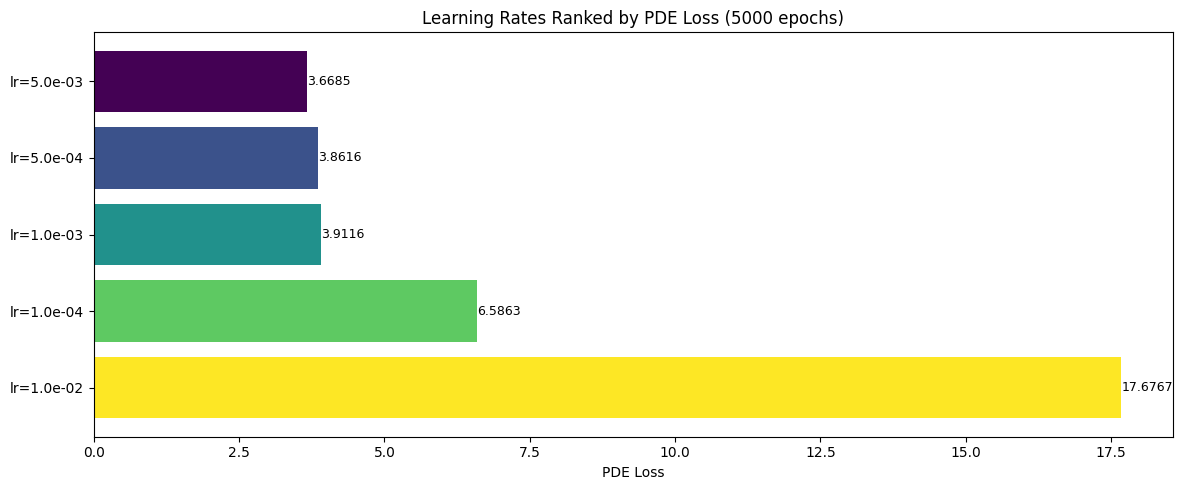

In [9]:
df_ranked = df_sweep.sort_values('pde_loss').reset_index(drop=True)
labels = [f"lr={r['lr']:.1e}" for _, r in df_ranked.iterrows()]

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(df_ranked)))
bars = ax.barh(range(len(df_ranked)), df_ranked['pde_loss'], color=colors)
ax.set_yticks(range(len(df_ranked)))
ax.set_yticklabels(labels)
ax.set_xlabel('PDE Loss')
ax.set_title(f'Learning Rates Ranked by PDE Loss ({SWEEP_EPOCHS} epochs)')
ax.invert_yaxis()

for i, v in enumerate(df_ranked['pde_loss']):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(out_dir / "hyper_hs_lr_ranked.pdf", bbox_inches="tight")
plt.show()


In [10]:
if IN_COLAB:
    from google.colab import drive
    drive.flush_and_unmount()
    print("Google Drive flushed and unmounted safely.")


Google Drive flushed and unmounted safely.
